In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from qiskit.quantum_info import Operator
 
single_gates = ['x', 'y', 'z', 'h', 's', 't']
for g in single_gates:
    qc = QuantumCircuit(1)
    getattr(qc, g)(0)
    print(g.upper(), 'matrix:')
    print(Operator(qc).data.round(3))
    print(g.upper(), 'applied to |0>:', Statevector.from_instruction(qc))
    print('-' * 40)

X matrix:
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
X applied to |0>: Statevector([0.+0.j, 1.+0.j],
            dims=(2,))
----------------------------------------
Y matrix:
[[0.+0.j 0.-1.j]
 [0.+1.j 0.+0.j]]
Y applied to |0>: Statevector([0.+0.j, 0.+1.j],
            dims=(2,))
----------------------------------------
Z matrix:
[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]
Z applied to |0>: Statevector([1.+0.j, 0.+0.j],
            dims=(2,))
----------------------------------------
H matrix:
[[ 0.707+0.j  0.707+0.j]
 [ 0.707+0.j -0.707+0.j]]
H applied to |0>: Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))
----------------------------------------
S matrix:
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+1.j]]
S applied to |0>: Statevector([1.+0.j, 0.+0.j],
            dims=(2,))
----------------------------------------
T matrix:
[[1.   +0.j    0.   +0.j   ]
 [0.   +0.j    0.707+0.707j]]
T applied to |0>: Statevector([1.+0.j, 0.+0.j],
            dims=(2,))
---------------------------------------

In [5]:
# (a) H applied twice should return the qubit to its starting state
qc_hh = QuantumCircuit(1)
qc_hh.h(0)
qc_hh.h(0)        # TODO: apply H a second time
print('H*H |0>  =', Statevector.from_instruction(qc_hh))
 
# (b) S applied twice should equal a single Z gate
qc_ss = QuantumCircuit(1)
qc_ss.s(0); qc_ss.s(0)
print('S*S matrix =')
print(Operator(qc_ss).data.round(3))
 
# (c) T applied twice should equal a single S gate
qc_tt = QuantumCircuit(1)
qc_tt.t(0); qc_tt.t(0)
print('T*T matrix =')
print(Operator(qc_tt).data.round(3))
 
# (d) Conjugating X by H (H X H) should equal Z
qc_hxh = QuantumCircuit(1)
qc_hxh.h(0); qc_hxh.x(0); qc_hxh.h(0)   # TODO: apply the final H
print('H*X*H matrix =')
print(Operator(qc_hxh).data.round(3))

H*H |0>  = Statevector([1.+0.j, 0.+0.j],
            dims=(2,))
S*S matrix =
[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]
T*T matrix =
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+1.j]]
H*X*H matrix =
[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]


RX(pi/2) |0> = [0.7071+0.j     0.    -0.7071j]  probs=[0.5 0.5]
RY(pi/2) |0> = [0.7071+0.j 0.7071+0.j]  probs=[0.5 0.5]
RZ(pi/2) |0> = [0.7071-0.7071j 0.    +0.j    ]  probs=[1. 0.]
RX(pi) |0> = [0.+0.j 0.-1.j]  probs=[0. 1.]
RY(pi) |0> = [0.+0.j 1.+0.j]  probs=[0. 1.]
RZ(pi) |0> = [0.-1.j 0.+0.j]  probs=[1. 0.]


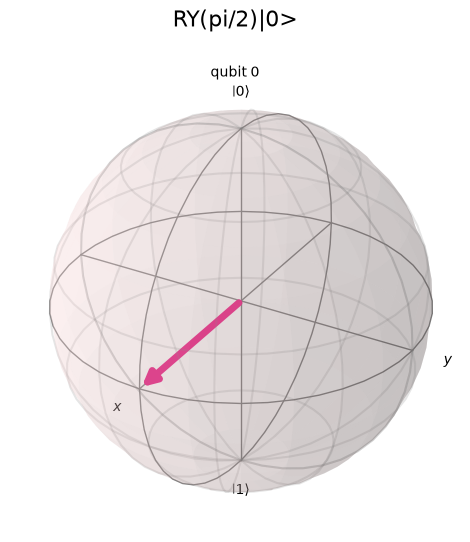

In [7]:
angles = {'pi/2': np.pi/2, 'pi': np.pi}
for name, theta in angles.items():
    for gate in ['rx', 'ry', 'rz']:
        qc = QuantumCircuit(1)
        getattr(qc, gate)(theta, 0)      # TODO: pass the rotation angle 'theta'
        sv = Statevector.from_instruction(qc)
        print(f'{gate.upper()}({name}) |0> = {sv.data.round(4)}  probs={sv.probabilities().round(4)}')
 
# Visualize one of them
qc_vis = QuantumCircuit(1)
qc_vis.ry(np.pi/2, 0)
plot_bloch_multivector(Statevector.from_instruction(qc_vis), title='RY(pi/2)|0>')
plt.show()

In [10]:
theta = 2 * np.arccos(0.6)
phi = 0.9273
 
qc4 = QuantumCircuit(1)
qc4.ry(theta, 0)
qc4.rz(phi, 0)      # TODO: apply the second rotation gate to set the phase
 
state4 = Statevector.from_instruction(qc4)
print('Prepared state:', state4.data.round(4))
print('Probabilities:', state4.probabilities().round(4))
# Check: probabilities should be close to [0.36, 0.64]

Prepared state: [0.5367-0.2683j 0.7155+0.3578j]
Probabilities: [0.36 0.64]
